# Phần 2 — Ứng dụng LSI cho Tóm tắt Văn bản Trích xuất 

**Tóm tắt trích xuất (Extractive Summarization)** là phương pháp chọn lọc các câu quan trọng nhất có sẵn trong văn bản gốc và ghép chúng thành một bản tóm tắt hoàn chỉnh. Mỗi câu được giữ **nguyên văn**, hệ thống không tự sinh câu mới hay sửa đổi từ ngữ.

**LSI (Latent Semantic Indexing)** ánh xạ văn bản từ không gian từ vựng có số chiều rất lớn (High-dimensional Term Space) sang không gian ngữ nghĩa tiềm ẩn (Latent Semantic Space) có số chiều $k$ nhỏ hơn nhờ phép phân rã giá trị suy biến **SVD (Singular Value Decomposition)**. Trong bài toán tóm tắt đơn văn bản, **mỗi câu được xem như một document**.



## Phần 1 — Import và Thiết lập


In [1]:
!pip -q install numpy pandas scikit-learn matplotlib

import math
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer

np.random.seed(42)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12, "font.family": "DejaVu Sans"})

def show_table(frame, digits=3):
    """Hiển thị bảng dữ liệu với số thực được làm tròn để dễ đọc."""
    display(frame.round(digits))

print("Đã import và thiết lập môi trường thành công.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã import và thiết lập môi trường thành công.


## Phần 2 — Dữ liệu Đầu vào

### Input
Một đoạn văn bản tiếng Việt gồm 10 câu về chủ đề ứng dụng trí tuệ nhân tạo trong giáo dục.

### Xử lý
Lưu chuỗi văn bản vào biến `document` và hiển thị nguyên văn.

### Output
Chuỗi văn bản 10 câu hoàn chỉnh.

### Ý nghĩa
Văn bản mẫu có độ dài vừa đủ để quan sát tường minh từng bước biến đổi đại số mà không bị che khuất.

In [2]:
document = """
Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.
Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.
Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.
Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.
Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.
Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.
Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.
Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.
Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.
Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.
""".strip()

display(Markdown("### Văn bản đầu vào:\n\n" + document))

### Văn bản đầu vào:

Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.
Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.
Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.
Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.
Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.
Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.
Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.
Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.
Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.
Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.

## Phần 3 — Tách câu (Sentence Segmentation)



In [3]:
def split_sentences(text):
    """Tách câu theo dấu kết thúc, giữ nguyên chữ và dấu câu."""
    if not isinstance(text, str):
        raise TypeError("text phải là chuỗi.")
    return [part.strip() for part in re.split(r"(?<=[.!?])\s+", text.strip()) if part.strip()]

sentences = split_sentences(document)
sentence_ids = [f"S{i + 1}" for i in range(len(sentences))]
sentence_df = pd.DataFrame({
    "sentence_id": sentence_ids,
    "original_position": np.arange(len(sentences)),
    "sentence": sentences
})
show_table(sentence_df[["sentence_id", "sentence"]])
print(f"Tổng số câu: {len(sentences)}. Mỗi hàng trong ma trận sẽ tương ứng với 1 câu.")

,sentence_id,sentence
0,S1,Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.
1,S2,Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.
2,S3,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu."
3,S4,Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.
4,S5,Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.
5,S6,Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.
6,S7,"Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục."
7,S8,Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.
8,S9,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.
9,S10,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn."


Tổng số câu: 10. Mỗi hàng trong ma trận sẽ tương ứng với 1 câu.


## Phần 4 — Tiền xử lý (Preprocessing)

### Input
Danh sách các câu gốc.

### Xử lý
1. Chuẩn hóa font Unicode dựng sẵn (NFC), chuyển chữ thường (`lower()`).
2. Loại bỏ dấu câu và ký tự đặc biệt (`re.sub`).
3. Tách từ theo ranh giới từ.
4. Lọc bỏ tập stopword tiếng Việt thường gặp.

### Output
Chuỗi token đã chuẩn hóa (`processed_sentence`) dùng để xây dựng ma trận TF-IDF.

### Ý nghĩa
Giảm chiều không gian từ vựng và loại bỏ các từ dừng không mang nhiều giá trị phân biệt ngữ nghĩa. Câu trích xuất trong bản tóm tắt cuối cùng vẫn được giữ **nguyên văn**.

In [4]:
VI_STOPWORDS = {
    "là", "và", "của", "các", "cho", "được", "trong", "với", "một",
    "những", "có", "để", "khi", "theo", "này", "đó", "từ", "về",
    "trên", "cũng", "sau", "mỗi", "từng", "do", "ra", "hơn",
}

def preprocess_sentence(sentence):
    """Chuẩn hóa Unicode, chữ thường, bỏ ký tự đặc biệt và lọc stopword."""
    normalized = unicodedata.normalize("NFC", sentence).lower()
    cleaned = re.sub(r"[^\w\s]", " ", normalized, flags=re.UNICODE)
    tokens = re.findall(r"(?u)\b\w+\b", cleaned)
    return " ".join(token for token in tokens if token not in VI_STOPWORDS)

processed_sentences = [preprocess_sentence(s) for s in sentences]
preprocessing_df = pd.DataFrame({
    "ID": sentence_ids,
    "original_sentence": sentences,
    "tokens": [p.split() for p in processed_sentences],
    "processed_sentence": processed_sentences,
})
show_table(preprocessing_df[["ID", "original_sentence", "processed_sentence"]])

,ID,original_sentence,processed_sentence
0,S1,Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.,trí tuệ nhân tạo đang thay đổi cách dạy học nhiều trường đại học
1,S2,Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.,hệ thống học tập cá nhân hóa thể đề xuất bài tập phù hợp năng lực sinh viên
2,S3,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.",sinh viên làm bài nền tảng phân tích kết quả phát hiện kiến thức còn yếu
3,S4,Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.,giảng viên sử dụng dữ liệu học tập điều chỉnh bài giảng hỗ trợ sinh viên kịp thời
4,S5,Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.,công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh bài tập
5,S6,Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.,trợ lý học tập dùng trí tuệ nhân tạo thể giải đáp câu hỏi ngoài giờ lên lớp
6,S7,"Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.",tuy nhiên dữ liệu cá nhân sinh viên cần bảo vệ mọi hệ thống giáo dục
7,S8,Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.,nhà trường phải kiểm tra độ chính xác gợi ý trí tuệ nhân tạo tạo
8,S9,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.,giảng viên vẫn giữ vai trò quan trọng việc định hướng đánh giá tư duy người học
9,S10,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.",kết hợp công nghệ chuyên môn sư phạm giáo dục thể trở nên linh hoạt hiệu quả


## Phần 5 — Xây dựng Ma trận TF-IDF ($A$)

### Input
Danh sách các câu đã qua tiền xử lý.

### Xử lý
Áp dụng `TfidfVectorizer` để xây dựng từ điển từ vựng và tính toán trọng số TF-IDF cho từng từ trong từng câu.

### Output
Ma trận dense $A$ có kích thước $(m \times n) = (10 \times 113)$:
- Hàng: $m = 10$ câu ($S_1, \dots, S_{10}$).
- Cột: $n = 113$ từ khóa phân biệt (terms).
- Giá trị $A_{ij}$: Trọng số TF-IDF của từ $j$ trong câu $i$.

### Ý nghĩa
Số hóa văn bản thành ma trận toán học nhiều chiều, làm đầu vào cho thuật toán phân rã SVD.

In [5]:
vectorizer = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = vectorizer.fit_transform(processed_sentences)
tfidf_matrix_dense = tfidf_matrix.toarray()
tfidf_df = pd.DataFrame(
    tfidf_matrix_dense,
    index=sentence_ids,
    columns=vectorizer.get_feature_names_out(),
)
print(f"Kích thước ma trận TF-IDF (A): {tfidf_matrix_dense.shape} = (số câu, số từ)")
show_table(tfidf_df.iloc[:, :12])

Kích thước ma trận TF-IDF (A): (10, 113) = (số câu, số từ)


,bài,bảo,chuyên,chính,chỉnh,cá,cách,câu,còn,công,cần,cụ
S1,0.000,0.000,0.000,0.000,0.00,0.000,0.3,0.000,0.000,0.000,0.000,0.000
S2,0.184,0.000,0.000,0.000,0.00,0.236,0.0,0.000,0.000,0.000,0.000,0.000
S3,0.180,0.000,0.000,0.000,0.00,0.000,0.0,0.000,0.272,0.000,0.000,0.000
S4,0.172,0.000,0.000,0.000,0.26,0.000,0.0,0.000,0.000,0.000,0.000,0.000
S5,0.191,0.000,0.000,0.000,0.00,0.000,0.0,0.000,0.000,0.246,0.000,0.289
S6,0.000,0.000,0.000,0.000,0.00,0.000,0.0,0.267,0.000,0.000,0.000,0.000
S7,0.000,0.288,0.000,0.000,0.00,0.245,0.0,0.000,0.000,0.000,0.288,0.000
S8,0.000,0.000,0.000,0.276,0.00,0.000,0.0,0.000,0.000,0.000,0.000,0.000
S9,0.000,0.000,0.000,0.000,0.00,0.000,0.0,0.000,0.000,0.000,0.000,0.000
S10,0.000,0.000,0.259,0.000,0.00,0.000,0.0,0.000,0.000,0.220,0.000,0.000


## Phần 6 — Trực quan hóa Ma trận TF-IDF

### Input
Ma trận TF-IDF $A$.

### Xử lý
Lọc ra 18 từ khóa có tổng trọng số TF-IDF lớn nhất trong toàn bộ văn bản và vẽ biểu đồ nhiệt (Heatmap) trên 10 câu.

### Output
Biểu đồ Heatmap biểu diễn mật độ trọng số từ vựng trên các câu.

### Ý nghĩa
Minh họa trực quan cấu trúc của ma trận TF-IDF và mức độ thưa (sparsity) trước khi phân rã.

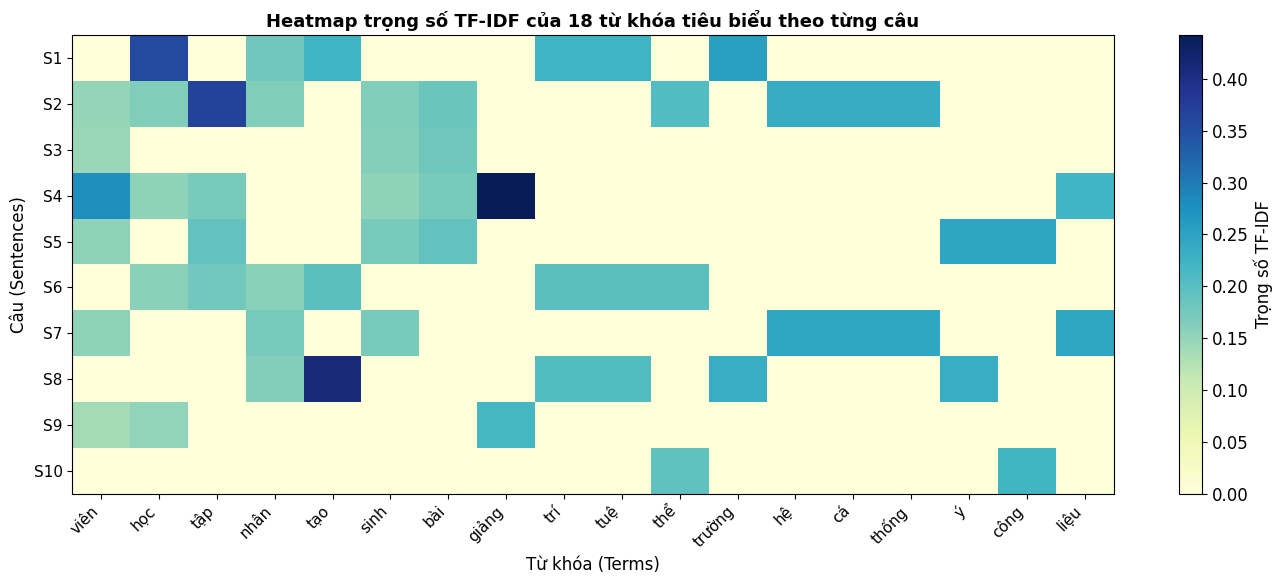

In [6]:
top_terms_idx = np.argsort(tfidf_matrix_dense.sum(axis=0))[::-1][:18]
top_terms = [vectorizer.get_feature_names_out()[i] for i in top_terms_idx]
top_tfidf_submatrix = tfidf_matrix_dense[:, top_terms_idx]

fig, ax = plt.subplots(figsize=(14, 6))
cax = ax.imshow(top_tfidf_submatrix, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(top_terms)))
ax.set_xticklabels(top_terms, rotation=45, ha="right", fontsize=11)
ax.set_yticks(range(len(sentence_ids)))
ax.set_yticklabels(sentence_ids, fontsize=11)
ax.set_title("Heatmap trọng số TF-IDF của 18 từ khóa tiêu biểu theo từng câu", fontsize=13, fontweight="bold")
ax.set_xlabel("Từ khóa (Terms)", fontsize=12)
ax.set_ylabel("Câu (Sentences)", fontsize=12)
fig.colorbar(cax, ax=ax, label="Trọng số TF-IDF")
fig.tight_layout()
plt.show()

## Phần 7 — Phân rã Ma trận SVD ($A = U \Sigma V^\top$)

### Cơ sở lý thuyết:
Phép phân rã giá trị suy biến **SVD (Singular Value Decomposition)** phân tích ma trận $A$ kích thước $m \times n$ thành tích của 3 ma trận:
$$A = U \Sigma V^\top$$

Trong đó:
- $U$ ($m \times r$): Ma trận trực giao gồm các vector riêng trái của $A A^\top$. Mỗi hàng biểu diễn một **câu** trong không gian các chủ đề tiềm ẩn (Latent Dimensions).
- $\Sigma$ ($r \times r$): Ma trận đường chéo chứa các giá trị suy biến (Singular Values) sắp xếp giảm dần $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0$. $\sigma_j$ thể hiện mức năng lượng/tầm quan trọng của chủ đề thứ $j$.
- $V^\top$ ($r \times n$): Ma trận trực giao gồm các vector riêng phải của $A^\top A$. Mỗi cột biểu diễn một **từ khóa** trên các chiều tiềm ẩn.
- Với dữ liệu hiện tại: $r = \min(m, n) = 10$.

In [7]:
U, S, VT = np.linalg.svd(tfidf_matrix_dense, full_matrices=False)
Sigma = np.diag(S)
latent_ids = [f"D{i + 1}" for i in range(len(S))]

reconstruction_error = np.linalg.norm(tfidf_matrix_dense - U @ Sigma @ VT)
print("Kích thước ma trận U:", U.shape)
print("Kích thước vector S:", S.shape)
print("Kích thước ma trận VT:", VT.shape)
print(f"Sai số tái tạo ||A - UΣVᵀ||_F: {reconstruction_error:.2e} (xấp xỉ 0)")

display(Markdown("### Ma trận U (Tọa độ câu trên các chiều tiềm ẩn):"))
show_table(pd.DataFrame(U, index=sentence_ids, columns=latent_ids))

display(Markdown("### Ma trận đường chéo Σ (Các giá trị suy biến):"))
show_table(pd.DataFrame(Sigma, index=latent_ids, columns=latent_ids))

display(Markdown("### Ma trận Vᵀ (12 term đầu tiên):"))
show_table(pd.DataFrame(VT[:, :12], index=latent_ids, columns=tfidf_df.columns[:12]))

Kích thước ma trận U: (10, 10)
Kích thước vector S: (10,)
Kích thước ma trận VT: (10, 113)
Sai số tái tạo ||A - UΣVᵀ||_F: 3.16e-15 (xấp xỉ 0)


### Ma trận U (Tọa độ câu trên các chiều tiềm ẩn):

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
S1,-0.323,-0.513,-0.012,-0.040,-0.142,0.106,-0.173,-0.162,-0.702,0.226
S2,-0.470,0.199,0.075,0.291,0.131,0.004,0.187,-0.589,-0.044,-0.498
S3,-0.192,0.259,0.228,-0.633,-0.172,0.608,0.044,-0.146,0.109,0.089
S4,-0.400,0.234,-0.422,-0.014,0.066,0.168,0.111,0.650,-0.237,-0.288
S5,-0.280,0.197,0.062,-0.380,0.660,-0.436,-0.141,-0.033,-0.057,0.292
S6,-0.365,-0.371,0.036,0.056,-0.017,-0.053,0.692,0.105,0.344,0.336
S7,-0.362,0.279,0.108,0.523,-0.101,0.185,-0.428,0.083,0.219,0.472
S8,-0.268,-0.525,0.146,-0.146,0.079,0.008,-0.463,0.165,0.442,-0.408
S9,-0.175,0.070,-0.649,-0.244,-0.460,-0.335,-0.149,-0.281,0.226,0.086
S10,-0.179,0.202,0.552,-0.101,-0.515,-0.501,0.039,0.240,-0.145,-0.124


### Ma trận đường chéo Σ (Các giá trị suy biến):

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
D1,1.316,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D2,0.000,1.163,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D3,0.000,0.000,1.041,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D4,0.000,0.000,0.000,0.999,0.000,0.000,0.000,0.000,0.000,0.000
D5,0.000,0.000,0.000,0.000,0.982,0.000,0.000,0.000,0.000,0.000
D6,0.000,0.000,0.000,0.000,0.000,0.942,0.000,0.000,0.000,0.000
D7,0.000,0.000,0.000,0.000,0.000,0.000,0.923,0.000,0.000,0.000
D8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.872,0.000,0.000
D9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.848,0.000
D10,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.808


### Ma trận Vᵀ (12 term đầu tiên):

,bài,bảo,chuyên,chính,chỉnh,cá,cách,câu,còn,công,cần,cụ
D1,-0.185,-0.079,-0.035,-0.056,-0.079,-0.152,-0.073,-0.074,-0.040,-0.082,-0.079,-0.062
D2,0.138,0.069,0.045,-0.125,0.052,0.099,-0.132,-0.085,0.061,0.080,0.069,0.049
D3,-0.006,0.030,0.137,0.039,-0.105,0.042,-0.003,0.009,0.060,0.131,0.030,0.017
D4,-0.136,0.151,-0.026,-0.040,-0.004,0.197,-0.012,0.015,-0.172,-0.116,0.151,-0.110
D5,0.133,-0.030,-0.136,0.022,0.017,0.006,-0.043,-0.005,-0.048,0.050,-0.030,0.194
D6,0.059,0.057,-0.138,0.002,0.046,0.049,0.034,-0.015,0.176,-0.231,0.057,-0.134
D7,0.037,-0.134,0.011,-0.139,0.031,-0.066,-0.056,0.200,0.013,-0.028,-0.134,-0.044
D8,-0.033,0.027,0.071,0.052,0.194,-0.136,-0.056,0.032,-0.045,0.051,0.027,-0.011
D9,-0.047,0.074,-0.044,0.144,-0.073,0.051,-0.248,0.108,0.035,-0.054,0.074,-0.019
D10,-0.086,0.168,-0.040,-0.139,-0.093,-0.002,0.084,0.111,0.030,0.055,0.168,0.105


## Phần 8 — Singular Values & Năng lượng Tích lũy (Cumulative Energy)

### Input
Vector các singular values $S = [\sigma_1, \sigma_2, \dots, \sigma_{10}]$.

### Xử lý
- Tỉ lệ năng lượng của chiều tiềm ẩn thứ $j$:
  $$E_j = \frac{\sigma_j^2}{\sum_{l=1}^r \sigma_l^2}$$
- Tỉ lệ năng lượng tích lũy khi giữ $k$ chiều đầu tiên:
  $$\text{Cumulative Energy}(k) = \frac{\sum_{j=1}^k \sigma_j^2}{\sum_{l=1}^r \sigma_l^2}$$
- Vẽ biểu đồ đường kết hợp: Biến thiên Singular Values và Năng lượng tích lũy kèm vạch ngưỡng $80\%$.

### Output
Bảng và biểu đồ năng lượng tích lũy.

### Ý nghĩa
Cơ sở định lượng chính xác để chọn số chiều $k$ tối ưu cho LSI.

,Latent Dimension,Singular Value,Tỉ lệ năng lượng,Năng lượng tích lũy
0,1,1.316,0.173,0.173
1,2,1.163,0.135,0.308
2,3,1.041,0.108,0.417
3,4,0.999,0.100,0.517
4,5,0.982,0.096,0.613
5,6,0.942,0.089,0.702
6,7,0.923,0.085,0.787
7,8,0.872,0.076,0.863
8,9,0.848,0.072,0.935
9,10,0.808,0.065,1.000


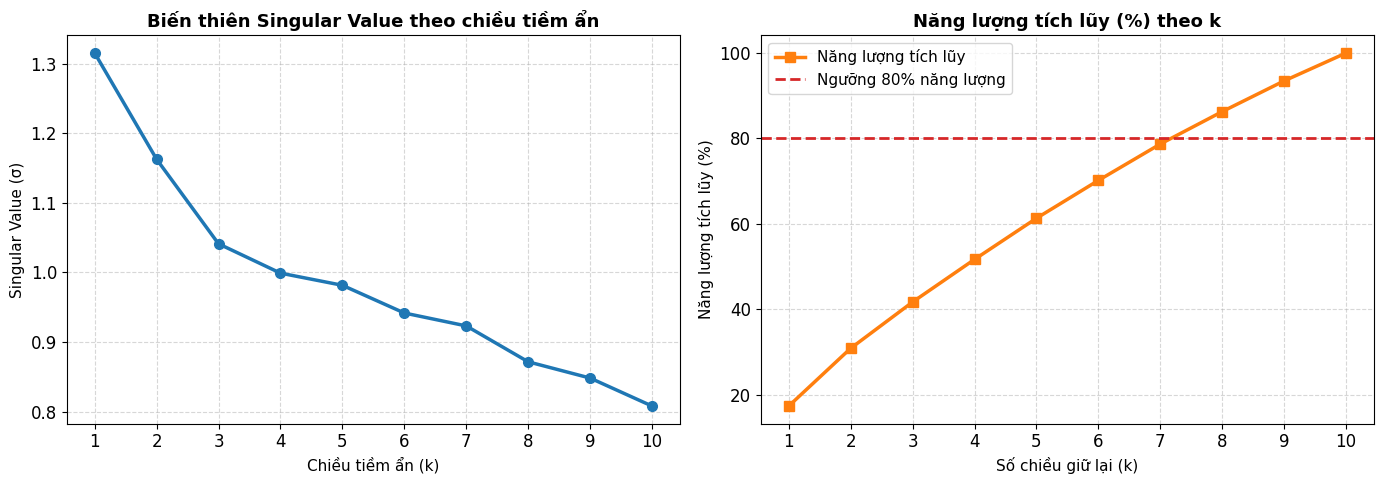

In [8]:
energy_ratios = S**2 / np.sum(S**2)
cum_energy = np.cumsum(energy_ratios)

singular_df = pd.DataFrame({
    "Latent Dimension": np.arange(1, len(S) + 1),
    "Singular Value": S,
    "Tỉ lệ năng lượng": energy_ratios,
    "Năng lượng tích lũy": cum_energy,
})
show_table(singular_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị Singular Values
ax1.plot(singular_df["Latent Dimension"], S, marker="o", color="tab:blue", linewidth=2.5, markersize=7)
ax1.set_xticks(singular_df["Latent Dimension"])
ax1.set_title("Biến thiên Singular Value theo chiều tiềm ẩn", fontsize=13, fontweight="bold")
ax1.set_xlabel("Chiều tiềm ẩn (k)", fontsize=11)
ax1.set_ylabel("Singular Value (σ)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)

# Đồ thị Năng lượng tích lũy
ax2.plot(singular_df["Latent Dimension"], cum_energy * 100, marker="s", color="tab:orange", linewidth=2.5, markersize=7, label="Năng lượng tích lũy")
ax2.axhline(y=80, color="tab:red", linestyle="--", linewidth=2, label="Ngưỡng 80% năng lượng")
ax2.set_xticks(singular_df["Latent Dimension"])
ax2.set_title("Năng lượng tích lũy (%) theo k", fontsize=13, fontweight="bold")
ax2.set_xlabel("Số chiều giữ lại (k)", fontsize=11)
ax2.set_ylabel("Năng lượng tích lũy (%)", fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
plt.show()

## Phần 9 — Chọn số chiều $k$ Tự động ($k = \min \{ k : \text{Cumulative Energy} \ge 80\% \}$)

### Input
Vector năng lượng tích lũy `cum_energy` và ngưỡng cấu hình `ENERGY_THRESHOLD = 0.80`.

### Xử lý
Thuật toán tự động tìm số chiều nhỏ nhất $k$ sao cho năng lượng tích lũy đạt từ $80\%$ trở lên:
$$k = \min \{ k : \text{Cumulative Energy}(k) \ge 80\% \}$$
Code: `k = int(np.argmax(cum_energy >= ENERGY_THRESHOLD) + 1)`

### Output
Giá trị $k$ tự động tìm được và tỉ lệ năng lượng thực tế bảo toàn.

### Ý nghĩa
Loại bỏ việc gán cứng tham số $k$, giúp hệ thống tự động thích ứng với từng văn bản cụ thể dựa trên cơ sở toán học vững chắc.

In [9]:
ENERGY_THRESHOLD = 0.80
k = int(np.argmax(cum_energy >= ENERGY_THRESHOLD) + 1)
retained_energy = cum_energy[k - 1]

print("=" * 60)
print(f"Ngưỡng năng lượng yêu cầu: >= {ENERGY_THRESHOLD:.0%}")
print(f"Số chiều tự động tìm được: k = {k}")
print(f"Tỉ lệ năng lượng thực tế bảo toàn: {retained_energy:.2%}")
print("=" * 60)

Ngưỡng năng lượng yêu cầu: >= 80%
Số chiều tự động tìm được: k = 8
Tỉ lệ năng lượng thực tế bảo toàn: 86.28%


## Phần 10 — Xây dựng Không gian LSI Rút gọn ($U_k, \Sigma_k, V_k^\top$)

### Input
Các ma trận $U, \Sigma, V^\top$ và số chiều $k$ tự động vừa xác định.

### Xử lý
Cắt giảm số chiều bằng cách chỉ giữ lại $k$ cột đầu của $U$, $k \times k$ khối đường chéo của $\Sigma$, và $k$ hàng đầu của $V^\top$:
$$U_k = U[:, :k], \quad \Sigma_k = \Sigma[:k, :k], \quad V_k^\top = V^\top[:k, :]$$

### Output
Các ma trận rút gọn trong không gian LSI:
- $U_k$: kích thước $(10 \times k)$
- $\Sigma_k$: kích thước $(k \times k)$
- $V_k^\top$: kích thước $(k \times 113)$

In [10]:
U_k = U[:, :k]
S_k = S[:k]
Sigma_k = np.diag(S_k)
VT_k = VT[:k, :]

print(f"Kích thước U_k: {U_k.shape}")
print(f"Kích thước Sigma_k: {Sigma_k.shape}")
print(f"Kích thước VT_k: {VT_k.shape}")

Kích thước U_k: (10, 8)
Kích thước Sigma_k: (8, 8)
Kích thước VT_k: (8, 113)


## Phần 11 — Biểu diễn Vector các Câu (Sentence Representation)

### Input
Ma trận $U_k$ và $\Sigma_k$.

### Xử lý
Tọa độ biểu diễn của các câu trong không gian ngữ nghĩa tiềm ẩn được tính bằng:
$$\text{Sentence Vectors} = U_k \Sigma_k$$
- Ma trận kết quả có kích thước $10 \times k$.
- Hàng thứ $i$ chính là vector đặc trưng của câu thứ $i$:
  $$s_i = U_k \Sigma_k(i, :)$$

### Output
Bảng vector biểu diễn 10 câu trong không gian $k$ chiều tiềm ẩn và biểu đồ phân tán trên 2 chiều chủ đề đầu tiên.

### Bảng Vector biểu diễn 10 câu trong không gian LSI (k = 8):

,D1,D2,D3,D4,D5,D6,D7,D8
S1,-0.424,-0.596,-0.012,-0.040,-0.139,0.100,-0.160,-0.141
S2,-0.619,0.231,0.078,0.291,0.129,0.004,0.173,-0.514
S3,-0.253,0.302,0.237,-0.633,-0.169,0.573,0.040,-0.127
S4,-0.527,0.272,-0.439,-0.014,0.065,0.158,0.103,0.566
S5,-0.369,0.229,0.065,-0.380,0.648,-0.410,-0.130,-0.029
S6,-0.480,-0.432,0.037,0.056,-0.016,-0.050,0.639,0.091
S7,-0.477,0.324,0.112,0.523,-0.099,0.175,-0.395,0.072
S8,-0.352,-0.610,0.152,-0.145,0.077,0.008,-0.428,0.144
S9,-0.230,0.081,-0.676,-0.244,-0.451,-0.315,-0.138,-0.245
S10,-0.236,0.235,0.574,-0.101,-0.506,-0.472,0.036,0.209


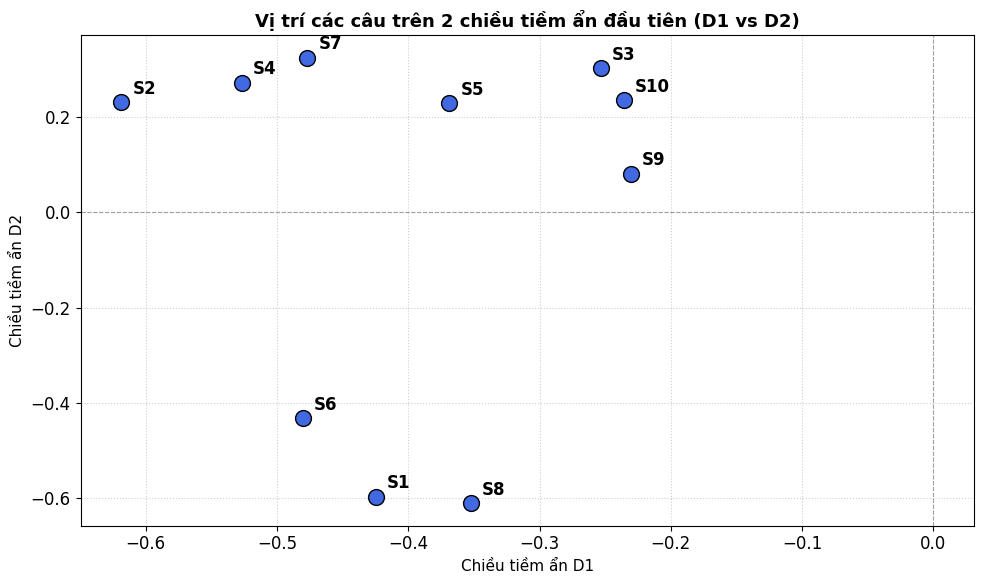

In [11]:
sentence_vectors = U_k @ Sigma_k

sentence_vec_df = pd.DataFrame(
    sentence_vectors,
    index=sentence_ids,
    columns=[f"D{j + 1}" for j in range(k)],
)
display(Markdown(f"### Bảng Vector biểu diễn 10 câu trong không gian LSI (k = {k}):"))
show_table(sentence_vec_df)

# Trực quan hóa tọa độ các câu trên 2 chiều LSI đầu tiên
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sentence_vectors[:, 0], sentence_vectors[:, 1], color="royalblue", s=130, zorder=3, edgecolors="black")

for i, sid in enumerate(sentence_ids):
    ax.annotate(
        sid,
        (sentence_vectors[i, 0], sentence_vectors[i, 1]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=12,
        fontweight="bold"
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("Vị trí các câu trên 2 chiều tiềm ẩn đầu tiên (D1 vs D2)", fontsize=13, fontweight="bold")
ax.set_xlabel("Chiều tiềm ẩn D1", fontsize=11)
ax.set_ylabel("Chiều tiềm ẩn D2", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
plt.show()

## Phần 12 — Tính Điểm Quan trọng của Câu (Sentence Score) theo Chuẩn $L_2$ Norm

### Công thức toán học:
Vector biểu diễn của câu thứ $i$ trong không gian LSI là $s_i = U_k \Sigma_k(i, :)$. Điểm quan trọng của câu được định nghĩa là **chuẩn Euclidean $L_2$ norm**:

$$\text{Sentence Score}(s_i) = \|s_i\|_2 = \|U_k \Sigma_k(i, :)\|_2 = \sqrt{\sum_{j=1}^k (u_{ij} \sigma_j)^2}$$

- Code NumPy:
  ```python
  sentence_scores = np.linalg.norm(sentence_vectors, axis=1)
  ```

### Ý nghĩa:
Chuẩn $L_2$ đo lường chính xác **độ dài vector** của câu trong không gian LSI rút gọn. Câu có độ dài vector càng lớn chứng tỏ mang càng nhiều thông tin và năng lượng trên các chủ đề ngữ nghĩa quan trọng của văn bản.

### Bảng điểm quan trọng Sentence Score (Chuẩn L2 norm):

,sentence_id,sentence,score
0,S1,Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.,0.782
1,S2,Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.,0.915
2,S3,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.",0.993
3,S4,Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.,0.951
4,S5,Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.,0.971
5,S6,Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.,0.917
6,S7,"Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.",0.906
7,S8,Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.,0.866
8,S9,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.,0.979
9,S10,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.",0.987


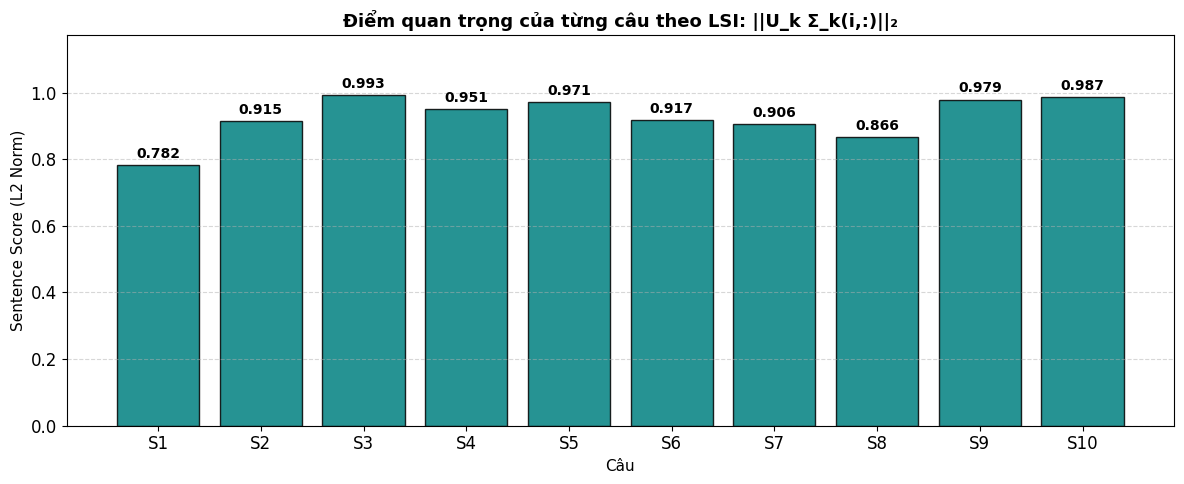

In [12]:
sentence_scores = np.linalg.norm(sentence_vectors, axis=1)

scores_df = pd.DataFrame({
    "sentence_id": sentence_ids,
    "sentence": sentences,
    "score": sentence_scores,
})
display(Markdown("### Bảng điểm quan trọng Sentence Score (Chuẩn L2 norm):"))
show_table(scores_df)

# Biểu đồ cột trực quan hóa điểm số của từng câu
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sentence_ids, sentence_scores, color="teal", edgecolor="black", alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10, fontweight="bold")
ax.set_ylim(0, max(sentence_scores) * 1.18)
ax.set_title("Điểm quan trọng của từng câu theo LSI: ||U_k Σ_k(i,:)||₂", fontsize=13, fontweight="bold")
ax.set_xlabel("Câu", fontsize=11)
ax.set_ylabel("Sentence Score (L2 Norm)", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

## Phần 13 — Xếp hạng Câu (Ranking)

### Input
Điểm $L_2$ norm của 10 câu.

### Xử lý
Sắp xếp các câu theo thứ tự điểm số giảm dần:
$$s_{(1)} \ge s_{(2)} \ge \dots \ge s_{(10)}$$
Nếu có hai câu bằng điểm nhau, ưu tiên câu xuất hiện trước trong văn bản gốc (`original_position`).

### Output
Bảng xếp hạng `ranking_df` gồm các trường `rank`, `sentence_id`, `original_position`, `sentence`, `score`.

In [13]:
ranking_df = pd.DataFrame({
    "sentence_id": sentence_ids,
    "original_position": np.arange(len(sentences)),
    "sentence": sentences,
    "score": sentence_scores,
}).sort_values(["score", "original_position"], ascending=[False, True]).reset_index(drop=True)
ranking_df.insert(0, "rank", np.arange(1, len(ranking_df) + 1))

display(Markdown("### Bảng xếp hạng câu theo Sentence Score:"))
show_table(ranking_df)

### Bảng xếp hạng câu theo Sentence Score:

,rank,sentence_id,original_position,sentence,score
0,1,S3,2,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.",0.993
1,2,S10,9,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.",0.987
2,3,S9,8,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.,0.979
3,4,S5,4,Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.,0.971
4,5,S4,3,Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.,0.951
5,6,S6,5,Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.,0.917
6,7,S2,1,Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.,0.915
7,8,S7,6,"Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.",0.906
8,9,S8,7,Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.,0.866
9,10,S1,0,Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.,0.782


## Phần 14 — Chọn Top-K Câu theo Tỉ lệ Nén (Top-K Selection)

### Input
Bảng xếp hạng câu `ranking_df` và tỉ lệ tóm tắt `summary_ratio = 0.3` (30% số câu).

### Xử lý
Xác định số câu cần trích xuất:
$$K = \lceil \text{summary\_ratio} \times N \rceil = \lceil 0.3 \times 10 \rceil = 3$$
Chọn $K$ câu đứng đầu bảng xếp hạng.

### Output
Danh sách các câu được chọn theo thứ tự điểm số.

In [14]:
summary_ratio = 0.3
num_sentences = None  # Đặt số nguyên nếu muốn chỉ định trực tiếp số câu
requested_count = num_sentences if num_sentences is not None else math.ceil(summary_ratio * len(sentences))
summary_count = min(max(1, int(requested_count)), len(sentences))

selected_by_score = ranking_df.head(summary_count).copy()
print(f"Tổng số câu gốc: {len(sentences)}")
print(f"Tỉ lệ tóm tắt: {summary_ratio:.0%}")
print(f"Số câu trích xuất được chọn (Top-{summary_count}): {summary_count}")
show_table(selected_by_score)

Tổng số câu gốc: 10
Tỉ lệ tóm tắt: 30%
Số câu trích xuất được chọn (Top-3): 3


,rank,sentence_id,original_position,sentence,score
0,1,S3,2,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.",0.993
1,2,S10,9,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.",0.987
2,3,S9,8,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.,0.979


## Phần 15 — Khôi phục Thứ tự Gốc (Original Sentence Order)

### Input
Top-$K$ câu được chọn theo điểm số giảm dần.

### Xử lý
Sắp xếp lại các câu đã chọn theo thứ tự xuất hiện ban đầu trong văn bản (`original_position` tăng dần).

### Output
Danh sách các câu tóm tắt đã khôi phục đúng trình tự ban đầu.

### Ý nghĩa
Đảm bảo tính mạch lạc, tự nhiên và logic diễn đạt của tác giả trong văn bản tóm tắt.

In [15]:
selected_ordered = selected_by_score.sort_values("original_position").reset_index(drop=True)
summary_sentences = selected_ordered["sentence"].tolist()

display(Markdown("### Các câu được chọn sắp xếp theo thứ tự ban đầu trong văn bản:"))
show_table(selected_ordered[["sentence_id", "original_position", "sentence", "score"]])

### Các câu được chọn sắp xếp theo thứ tự ban đầu trong văn bản:

,sentence_id,original_position,sentence,score
0,S3,2,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.",0.993
1,S9,8,Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.,0.979
2,S10,9,"Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.",0.987


## Phần 16 — Xuất Bản Tóm tắt Trích xuất (Extractive Summary)

### Input
Các câu đã được sắp xếp theo đúng thứ tự ban đầu.

### Xử lý
Ghép các câu bằng dấu cách để tạo thành bản tóm tắt hoàn chỉnh.

### Output
Bản tóm tắt trích xuất nguyên văn từ văn bản gốc.

In [16]:
summary = " ".join(summary_sentences)

display(Markdown("### VĂN BẢN GỐC:\n\n" + document))
display(Markdown("### BẢN TÓM TẮT TRÍCH XUẤT (EXTRACTIVE SUMMARY):\n\n" + summary))

### VĂN BẢN GỐC:

Trí tuệ nhân tạo đang thay đổi cách dạy và học trong nhiều trường đại học.
Hệ thống học tập cá nhân hóa có thể đề xuất bài tập phù hợp với năng lực của từng sinh viên.
Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu.
Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh viên kịp thời.
Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập.
Trợ lý học tập dùng trí tuệ nhân tạo có thể giải đáp câu hỏi ngoài giờ lên lớp.
Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thống giáo dục.
Nhà trường phải kiểm tra độ chính xác của gợi ý do trí tuệ nhân tạo tạo ra.
Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học.
Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.

### BẢN TÓM TẮT TRÍCH XUẤT (EXTRACTIVE SUMMARY):

Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học. Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.

## Phần 17 — Thống kê Kết quả & Tỉ lệ Nén

### Chỉ số đánh giá:
- **Tỉ lệ giữ lại (Compression Ratio)**: $\text{Ratio} = \frac{\text{Số câu tóm tắt}}{\text{Số câu gốc}} = \frac{K}{N}$
- **Mức độ rút gọn (Compression Percentage)**: $1 - \text{Ratio}$

In [17]:
compression_ratio = len(summary_sentences) / len(sentences)
statistics_df = pd.DataFrame({
    "Chỉ số": [
        "Số câu văn bản gốc (Original sentence count)",
        "Số câu bản tóm tắt (Summary sentence count)",
        "Tỉ lệ giữ lại (Compression ratio)",
        "Mức độ rút gọn (Compression percentage)",
        "Số chiều k tự động (k_auto)",
        "Năng lượng bảo toàn",
    ],
    "Giá trị": [
        len(sentences),
        len(summary_sentences),
        f"{compression_ratio:.0%}",
        f"{1 - compression_ratio:.0%}",
        k,
        f"{retained_energy:.1%}",
    ]
})
show_table(statistics_df)
print(f"Compression ratio = {len(summary_sentences)} / {len(sentences)} = {compression_ratio:.0%}")

,Chỉ số,Giá trị
0,Số câu văn bản gốc (Original sentence count),10
1,Số câu bản tóm tắt (Summary sentence count),3
2,Tỉ lệ giữ lại (Compression ratio),30%
3,Mức độ rút gọn (Compression percentage),70%
4,Số chiều k tự động (k_auto),8
5,Năng lượng bảo toàn,86.3%


Compression ratio = 3 / 10 = 30%


## Phần 18 — Kiểm tra Tính Đúng đắn của Bản Tóm tắt

Kiểm tra 4 điều kiện cốt lõi bằng các lệnh `assert`:
1. Mọi câu trong bản tóm tắt đều lấy nguyên văn từ văn bản gốc.
2. Không có câu nào bị trùng lặp.
3. Đúng số lượng câu $K$ đã định.
4. Các câu bảo toàn thứ tự xuất hiện ban đầu.

In [18]:
# 1. Nguyên văn
assert all(s in sentences and s in document for s in summary_sentences), "Lỗi: Có câu không nguyên văn!"
print("✓ Tiêu chí 1: Mọi câu trong summary đều lấy nguyên văn từ văn bản gốc.")

# 2. Không lặp câu
assert len(summary_sentences) == len(set(summary_sentences)), "Lỗi: Có câu bị lặp!"
print("✓ Tiêu chí 2: Không có câu nào bị trùng lặp trong bản tóm tắt.")

# 3. Đúng số câu
assert len(summary_sentences) == summary_count, "Lỗi: Sai số lượng câu!"
print(f"✓ Tiêu chí 3: Số câu tóm tắt đúng bằng K = {summary_count}.")

# 4. Đúng thứ tự gốc
assert selected_ordered["original_position"].is_monotonic_increasing, "Lỗi: Sai thứ tự xuất hiện!"
print("✓ Tiêu chí 4: Các câu theo đúng thứ tự xuất hiện ban đầu trong văn bản.")

✓ Tiêu chí 1: Mọi câu trong summary đều lấy nguyên văn từ văn bản gốc.
✓ Tiêu chí 2: Không có câu nào bị trùng lặp trong bản tóm tắt.
✓ Tiêu chí 3: Số câu tóm tắt đúng bằng K = 3.
✓ Tiêu chí 4: Các câu theo đúng thứ tự xuất hiện ban đầu trong văn bản.


## Phần 19 — Hàm Tổng hợp Hoàn chỉnh `lsi_summarize`

Đóng gói toàn bộ pipeline thành một hàm xử lý chuẩn, tự động thực hiện:
`Tách câu -> Tiền xử lý -> TF-IDF -> SVD -> Năng lượng tích lũy -> k tự động -> U_k Σ_k -> Score (L2 norm) -> Ranking -> Top-K -> Reorder -> Summary`

In [19]:
def lsi_summarize(text, num_sentences=None, summary_ratio=0.3, energy_threshold=0.80):
    """
    Hàm tóm tắt văn bản trích xuất hoàn chỉnh bằng LSI (k tự động theo năng lượng >= 80%).
    """
    raw_sentences = split_sentences(text)
    if not raw_sentences:
        raise ValueError("Văn bản không có câu hợp lệ.")

    # 1. Tiền xử lý
    processed = [preprocess_sentence(s) for s in raw_sentences]
    if not any(processed):
        raise ValueError("Không còn token sau tiền xử lý.")

    # 2. Ma trận TF-IDF
    tfidf_vec = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\b\w+\b")
    A = tfidf_vec.fit_transform(processed).toarray()

    # 3. SVD
    local_U, local_S, local_VT = np.linalg.svd(A, full_matrices=False)

    # 4. Chọn k tự động
    local_energy = local_S**2 / np.sum(local_S**2)
    local_cum_energy = np.cumsum(local_energy)
    effective_k = int(np.argmax(local_cum_energy >= energy_threshold) + 1)

    # 5. Sentence representation & Sentence Score (L2 norm)
    local_vectors = local_U[:, :effective_k] @ np.diag(local_S[:effective_k])
    local_scores = np.linalg.norm(local_vectors, axis=1)

    # 6. Bảng xếp hạng
    ranking_data = pd.DataFrame({
        "sentence_id": [f"S{i + 1}" for i in range(len(raw_sentences))],
        "original_position": np.arange(len(raw_sentences)),
        "sentence": raw_sentences,
        "score": local_scores,
    }).sort_values(["score", "original_position"], ascending=[False, True]).reset_index(drop=True)
    ranking_data.insert(0, "rank", np.arange(1, len(ranking_data) + 1))

    # 7. Chọn Top-K
    if num_sentences is not None:
        target_count = min(max(1, int(num_sentences)), len(raw_sentences))
    else:
        target_count = min(max(1, math.ceil(summary_ratio * len(raw_sentences))), len(raw_sentences))

    chosen = ranking_data.head(target_count).sort_values("original_position").reset_index(drop=True)
    final_summary = " ".join(chosen["sentence"].tolist())

    info = {
        "k": effective_k,
        "energy_retained": local_cum_energy[effective_k - 1],
        "chosen_sentence_ids": chosen["sentence_id"].tolist(),
        "ranking_df": ranking_data,
    }
    return final_summary, info

# Kiểm thử hàm tổng hợp với văn bản mẫu
test_summary, test_info = lsi_summarize(document, summary_ratio=0.3, energy_threshold=0.80)
print("===== FINAL SUMMARY (FROM FUNCTION) =====\n")
print(test_summary)
print(f"\nSố chiều k tự động: {test_info['k']} (Năng lượng bảo toàn: {test_info['energy_retained']:.1%})")
print(f"Các câu được chọn: {', '.join(test_info['chosen_sentence_ids'])}")

# Kiểm tra tính khớp 100% với các bước chạy chi tiết bên trên
assert test_summary == summary
assert np.allclose(test_info["ranking_df"]["score"], ranking_df["score"])
print("\n✓ Kết quả hàm tổng hợp khớp chính xác 100% với từng bước thực hiện.")

===== FINAL SUMMARY (FROM FUNCTION) =====

Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư duy của người học. Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh hoạt và hiệu quả hơn.

Số chiều k tự động: 8 (Năng lượng bảo toàn: 86.3%)
Các câu được chọn: S3, S9, S10

✓ Kết quả hàm tổng hợp khớp chính xác 100% với từng bước thực hiện.


## Phần 20 — Thử nghiệm và Đánh giá

### Thử nghiệm 1: Thay đổi Ngưỡng Năng lượng Tích lũy (Energy Threshold)
Khảo sát số chiều $k$ tự động tìm được và các câu được chọn khi đặt các ngưỡng năng lượng từ $50\%$ đến $90\%$.

In [20]:
threshold_experiments = []
for thres in [0.50, 0.70, 0.80, 0.90]:
    sum_text, info = lsi_summarize(document, summary_ratio=0.3, energy_threshold=thres)
    threshold_experiments.append({
        "Ngưỡng năng lượng cài đặt": f"{thres:.0%}",
        "k tự động tìm được": info["k"],
        "Năng lượng thực tế": f"{info['energy_retained']:.1%}",
        "Mã câu được chọn": ", ".join(info["chosen_sentence_ids"]),
        "Bản tóm tắt": sum_text,
    })
show_table(pd.DataFrame(threshold_experiments))

,Ngưỡng năng lượng cài đặt,k tự động tìm được,Năng lượng thực tế,Mã câu được chọn,Bản tóm tắt
0,50%,4,51.7%,"S3, S7, S9","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Tuy nhiên, dữ liệu cá nhân của sinh viên cần được bảo vệ trong mọi hệ thốn..."
1,70%,6,70.2%,"S3, S5, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập. ..."
2,80%,8,86.3%,"S3, S9, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư..."
3,90%,9,93.5%,"S3, S9, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư..."


### Thử nghiệm 2: Thay đổi Tỉ lệ Tóm tắt (Summary Ratio)
Khảo sát độ dài bản tóm tắt khi thay đổi tỉ lệ nén từ $10\%$ đến $50\%$ với ngưỡng năng lượng chuẩn $80\%$.

In [21]:
ratio_experiments = []
for ratio in [0.10, 0.20, 0.30, 0.40, 0.50]:
    sum_text, info = lsi_summarize(document, summary_ratio=ratio, energy_threshold=0.80)
    count = math.ceil(ratio * len(sentences))
    ratio_experiments.append({
        "Tỉ lệ tóm tắt": f"{ratio:.0%}",
        "Số câu chọn (K)": len(info["chosen_sentence_ids"]),
        "Mã câu được chọn": ", ".join(info["chosen_sentence_ids"]),
        "Bản tóm tắt": sum_text,
    })
show_table(pd.DataFrame(ratio_experiments))

,Tỉ lệ tóm tắt,Số câu chọn (K),Mã câu được chọn,Bản tóm tắt
0,10%,1,S3,"Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu."
1,20%,2,"S3, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Khi kết hợp công nghệ với chuyên môn sư phạm, giáo dục có thể trở nên linh..."
2,30%,3,"S3, S9, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên vẫn giữ vai trò quan trọng trong việc định hướng và đánh giá tư..."
3,40%,4,"S3, S5, S9, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Công cụ phản hồi tự động giúp sinh viên nhận góp ý nhanh sau mỗi bài tập. ..."
4,50%,5,"S3, S4, S5, S9, S10","Khi sinh viên làm bài, nền tảng phân tích kết quả để phát hiện kiến thức còn yếu. Giảng viên sử dụng dữ liệu học tập để điều chỉnh bài giảng và hỗ trợ sinh ..."
